In [ ]:
"""
CST8506 Lab 3: Convolutional Neural Networks
Author: Peng Wang
Student Number: 041107730

This lab implements a CNN model to classify handwritten digits from the MNIST dataset.
The model uses Conv2D layers, MaxPooling, and Dense layers for classification.
"""

# 导入标准库模块
# Import standard library modules
import os
from datetime import datetime

# 禁用 TensorFlow 警告信息（必须在导入 TensorFlow 之前设置）
# Disable TensorFlow warning messages (must be set before importing TensorFlow)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # 只显示错误 / Only show errors
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'  # 禁用 oneDNN 警告 / Disable oneDNN warnings

import warnings
warnings.filterwarnings('ignore')  # 禁用 Keras UserWarning / Disable Keras UserWarning

# 导入科学计算和可视化库
# Import scientific computing and visualization libraries
import numpy as np
import matplotlib.pyplot as plt

# 导入环境变量加载库
# Import environment variable loading library
from dotenv import load_dotenv

# 导入 TensorFlow 和 Keras 模块
# Import TensorFlow and Keras modules
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [2]:
# ============================================================
# 配置常量
# Configuration Constants
# ============================================================
# 随机种子：学号后三位 041107730
# Random seed: last 3 digits of student number 041107730
SEED = 730

# 每批次训练样本数量
# Number of training samples per batch
BATCH_SIZE = 128

# 训练轮数
# Number of training epochs
EPOCHS = 10

# 验证集比例（10%用于验证）
# Validation split ratio (10% for validation)
VALIDATION_SPLIT = 0.1

# 第一个卷积层的滤波器数量
# Number of filters in first convolutional layer
FIRST_CONV_FILTERS = 32

# 第二个卷积层的滤波器数量
# Number of filters in second convolutional layer
SECOND_CONV_FILTERS = 64

# 卷积核大小（3x3像素）
# Kernel size (3x3 pixels)
KERNEL_SIZE = (3, 3)

# 池化窗口大小（2x2像素）
# Pooling window size (2x2 pixels)
POOL_SIZE = (2, 2)

# 全连接层神经元数量
# Number of neurons in dense layer
DENSE_UNITS = 128

# 输出类别数量（0-9共10个数字）
# Number of output classes (0-9 digits)
NUM_CLASSES = 10

# 图像尺寸（28x28像素）
# Image size (28x28 pixels)
IMAGE_SIZE = 28

# 颜色通道数（灰度图为1，RGB图为3）
# Number of color channels (1 for grayscale, 3 for RGB)
NUM_CHANNELS = 1


# ============================================================
# initialize_lab: 初始化实验环境，设置随机种子和输出目录
#                 Initialize lab environment, set random seed and output directory
#
# Returns:
#   output_dir: 输出目录路径
#               Output directory path
#   line_width: 分隔线宽度
#               Divider line width
# ============================================================
def initialize_lab():
    """初始化实验环境
    Initialize lab environment"""

    # 加载 .env.local 文件中的环境变量
    # Load environment variables from .env.local file
    load_dotenv('.env.local')

    # 设置随机种子以确保结果可重复
    # Set random seeds to ensure reproducible results
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    # 创建输出目录
    # Create output directory
    output_dir = 'lab3_images'
    os.makedirs(output_dir, exist_ok=True)

    # 获取学生信息和日期
    # Get student information and date
    line_width = 60
    student_name = os.getenv('NAME', 'Peng Wang')
    student_number = os.getenv('NUMBER', '041107730')
    current_date = datetime.now().strftime('%Y-%m-%d')

    print("=" * line_width)
    print("CST8506 - Lab 3: Convolutional Neural Networks")
    print(f"Author: {student_name}")
    print(f"Student Number: {student_number}")
    print(f"Date: {current_date}")
    print(f"Random Seed: {SEED}")
    print("=" * line_width)

    return output_dir, line_width

In [3]:
# ============================================================
# 步骤 0：实验初始化
# Step 0: Lab Initialization
# ============================================================
output_dir, line_width = initialize_lab()

CST8506 - Lab 3: Convolutional Neural Networks
Author: Peng Wang
Student Number: 041107730
Date: 2026-02-06
Random Seed: 730


In [4]:
# ============================================================
# 步骤 1：加载数据集
# Step 1: Load the Dataset
# ============================================================
print()
print("=" * line_width)
print("Step 1: Load the MNIST Dataset")
print("=" * line_width)

# 使用 Keras 加载 MNIST 数据集，返回训练集和测试集
# Load MNIST dataset using Keras, returns training and test sets
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Dataset loaded successfully.")
print(f"Training set shape: {x_train.shape}")
print(f"Test set shape: {x_test.shape}")


Step 1: Load the MNIST Dataset
Dataset loaded successfully.
Training set shape: (60000, 28, 28)
Test set shape: (10000, 28, 28)


In [5]:
# ============================================================
# 步骤 2：打印训练集和测试集的图像数量
# Step 2: Print the Number of Images in Train and Test Set
# ============================================================
print()
print("=" * line_width)
print("Step 2: Print the Number of Images in Train and Test Set")
print("=" * line_width)

# 使用 shape[0] 获取样本数量
# Use shape[0] to get the number of samples
num_train = x_train.shape[0]
num_test = x_test.shape[0]

print(f"Number of images in training set: {num_train}")
print(f"Number of images in test set: {num_test}")
print(f"Image dimensions: {x_train.shape[1]} x {x_train.shape[2]} pixels")


Step 2: Print the Number of Images in Train and Test Set
Number of images in training set: 60000
Number of images in test set: 10000
Image dimensions: 28 x 28 pixels



Step 3: Print First 5 Images in the Train Set


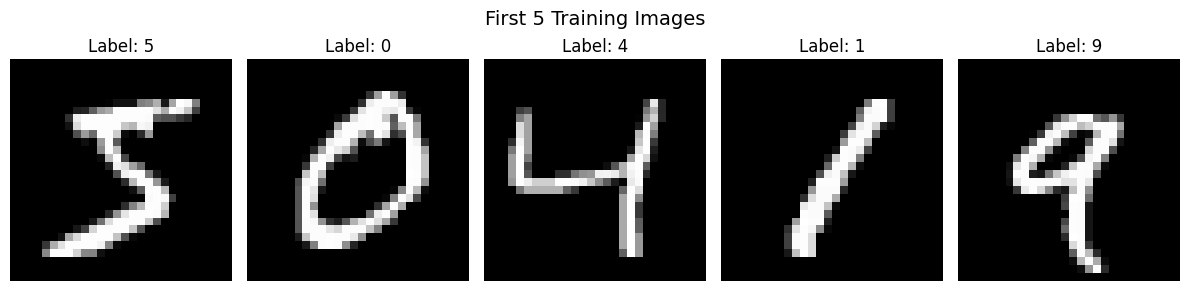

First 5 images displayed with their labels:
  Image 1: Label = 5
  Image 2: Label = 0
  Image 3: Label = 4
  Image 4: Label = 1
  Image 5: Label = 9
Figure saved to: lab3_images/step3_first_5_images.png


In [6]:
# ============================================================
# 步骤 3：显示前 5 张训练图像
# Step 3: Print First 5 Images in the Train Set
# ============================================================
print()
print("=" * line_width)
print("Step 3: Print First 5 Images in the Train Set")
print("=" * line_width)

# 创建 1x5 子图布局显示前 5 张图像
# Create 1x5 subplot layout to display first 5 images
fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for i in range(5):
    axes[i].imshow(x_train[i], cmap='gray')
    axes[i].set_title(f"Label: {y_train[i]}")
    axes[i].axis('off')

plt.suptitle("First 5 Training Images", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'step3_first_5_images.png'), dpi=150, bbox_inches='tight')
plt.show()

print("First 5 images displayed with their labels:")
for i in range(5):
    print(f"  Image {i+1}: Label = {y_train[i]}")
print(f"Figure saved to: {output_dir}/step3_first_5_images.png")

In [7]:
# ============================================================
# 步骤 4：重塑数据以设置通道
# Step 4: Reshape to Set the Channel
# ============================================================
print()
print("=" * line_width)
print("Step 4: Reshape to Set the Channel")
print("=" * line_width)

print(f"Original training shape: {x_train.shape}")
print(f"Original test shape: {x_test.shape}")

# 重塑：(samples, 28, 28) -> (samples, 28, 28, 1)
# 灰度图 channel=1，RGB 图 channel=3
# Reshape: (samples, 28, 28) -> (samples, 28, 28, 1)
# Grayscale channel=1, RGB channel=3
x_train = x_train.reshape(x_train.shape[0], IMAGE_SIZE, IMAGE_SIZE, NUM_CHANNELS)
x_test = x_test.reshape(x_test.shape[0], IMAGE_SIZE, IMAGE_SIZE, NUM_CHANNELS)

print(f"Reshaped training shape: {x_train.shape}")
print(f"Reshaped test shape: {x_test.shape}")
print("Channel dimension added (1 for grayscale images)")


Step 4: Reshape to Set the Channel
Original training shape: (60000, 28, 28)
Original test shape: (10000, 28, 28)
Reshaped training shape: (60000, 28, 28, 1)
Reshaped test shape: (10000, 28, 28, 1)
Channel dimension added (1 for grayscale images)


In [8]:
# ============================================================
# 步骤 5：归一化图像
# Step 5: Normalize the Images
# ============================================================
print()
print("=" * line_width)
print("Step 5: Normalize the Images")
print("=" * line_width)

print(f"Before normalization - Min: {x_train.min()}, Max: {x_train.max()}")

# 将像素值从 [0, 255] 归一化到 [0, 1]
# 原因：神经网络对小范围的输入值收敛更快更稳定
# Normalize pixel values from [0, 255] to [0, 1]
# Reason: Neural networks converge faster with smaller input ranges
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print(f"After normalization - Min: {x_train.min():.4f}, Max: {x_train.max():.4f}")
print("Normalization helps improve training stability and convergence speed.")


Step 5: Normalize the Images
Before normalization - Min: 0, Max: 255
After normalization - Min: 0.0000, Max: 1.0000
Normalization helps improve training stability and convergence speed.


In [9]:
# ============================================================
# 步骤 6：对标签进行 One-Hot 编码
# Step 6: Apply One-Hot Encoding on the Y Values
# ============================================================
print()
print("=" * line_width)
print("Step 6: Apply One-Hot Encoding on the Y Values")
print("=" * line_width)

# 保存原始标签用于后续评估
# Save original labels for later evaluation
y_train_original = y_train.copy()
y_test_original = y_test.copy()

# One-Hot 编码：数字 5 -> [0,0,0,0,0,1,0,0,0,0]
# One-Hot encoding: digit 5 -> [0,0,0,0,0,1,0,0,0,0]
y_train = to_categorical(y_train, NUM_CLASSES)
y_test = to_categorical(y_test, NUM_CLASSES)

print(f"Training labels shape: {y_train.shape}")
print(f"Test labels shape: {y_test.shape}")


Step 6: Apply One-Hot Encoding on the Y Values
Training labels shape: (60000, 10)
Test labels shape: (10000, 10)


In [10]:
# ============================================================
# 步骤 7：打印前 5 个实例的新旧标签值
# Step 7: Print Old and New Values for First 5 Instances of y_train
# ============================================================
print()
print("=" * line_width)
print("Step 7: Print Old and New Values for First 5 Instances of y_train")
print("=" * line_width)

print("Comparison of original labels and one-hot encoded labels:")
print("-" * line_width)

for i in range(5):
    original_label = y_train_original[i]
    encoded_label = y_train[i].astype(int)
    print(f"Instance {i+1}:")
    print(f"  Original label: {original_label}")
    print(f"  One-hot encoded: {encoded_label}")


Step 7: Print Old and New Values for First 5 Instances of y_train
Comparison of original labels and one-hot encoded labels:
------------------------------------------------------------
Instance 1:
  Original label: 5
  One-hot encoded: [0 0 0 0 0 1 0 0 0 0]
Instance 2:
  Original label: 0
  One-hot encoded: [1 0 0 0 0 0 0 0 0 0]
Instance 3:
  Original label: 4
  One-hot encoded: [0 0 0 0 1 0 0 0 0 0]
Instance 4:
  Original label: 1
  One-hot encoded: [0 1 0 0 0 0 0 0 0 0]
Instance 5:
  Original label: 9
  One-hot encoded: [0 0 0 0 0 0 0 0 0 1]


In [11]:
# ============================================================
# 步骤 8：构建 CNN 模型
# Step 8: Build the CNN Model
# ============================================================
print()
print("=" * line_width)
print("Step 8: Build the CNN Model")
print("=" * line_width)

# 构建 Sequential 模型
# 架构：Input -> Conv -> MaxPool -> Conv -> MaxPool -> Flatten -> Dense -> Dense
# Build Sequential model
# Architecture: Input -> Conv -> MaxPool -> Conv -> MaxPool -> Flatten -> Dense -> Dense
model = Sequential([
    # 第一个卷积层：32 个 3x3 滤波器，ReLU 激活，same 填充保持尺寸
    # First Conv layer: 32 3x3 filters, ReLU activation, same padding keeps size
    Conv2D(FIRST_CONV_FILTERS, KERNEL_SIZE, activation='relu', padding='same',
           input_shape=(IMAGE_SIZE, IMAGE_SIZE, NUM_CHANNELS)),

    # 第一个池化层：2x2 最大池化，维度减半
    # First pooling: 2x2 max pooling, halves dimensions
    MaxPooling2D(pool_size=POOL_SIZE),

    # 第二个卷积层：64 个滤波器学习更复杂的特征
    # Second Conv layer: 64 filters learn more complex features
    Conv2D(SECOND_CONV_FILTERS, KERNEL_SIZE, activation='relu', padding='same'),

    # 第二个池化层
    # Second pooling layer
    MaxPooling2D(pool_size=POOL_SIZE),

    # 展平层：将 2D 特征图 (7x7x64) 转换为 1D 向量 (3136)
    # Flatten: converts 2D feature maps (7x7x64) to 1D vector (3136)
    Flatten(),

    # 全连接层：128 神经元，学习特征的非线性组合
    # Dense layer: 128 neurons, learns non-linear feature combinations
    Dense(DENSE_UNITS, activation='relu'),

    # 输出层：10 个神经元，softmax 输出概率分布
    # Output layer: 10 neurons, softmax outputs probability distribution
    Dense(NUM_CLASSES, activation='softmax')
])

print("Model Architecture: Input -> Conv -> MaxPool -> Conv -> MaxPool -> Flatten -> Dense -> Dense")
print()
print("Layer Parameters:")
print(f"  Conv2D Layer 1: {FIRST_CONV_FILTERS} filters, kernel_size={KERNEL_SIZE}, "
      f"activation='relu', padding='same'")
print(f"  MaxPooling2D: pool_size={POOL_SIZE}")
print(f"  Conv2D Layer 2: {SECOND_CONV_FILTERS} filters, kernel_size={KERNEL_SIZE}, "
      f"activation='relu', padding='same'")
print(f"  MaxPooling2D: pool_size={POOL_SIZE}")
print(f"  Flatten: Converts 2D feature maps to 1D vector")
print(f"  Dense Layer 1: {DENSE_UNITS} units, activation='relu'")
print(f"  Dense Layer 2 (Output): {NUM_CLASSES} units, activation='softmax'")


Step 8: Build the CNN Model
Model Architecture: Input -> Conv -> MaxPool -> Conv -> MaxPool -> Flatten -> Dense -> Dense

Layer Parameters:
  Conv2D Layer 1: 32 filters, kernel_size=(3, 3), activation='relu', padding='same'
  MaxPooling2D: pool_size=(2, 2)
  Conv2D Layer 2: 64 filters, kernel_size=(3, 3), activation='relu', padding='same'
  MaxPooling2D: pool_size=(2, 2)
  Flatten: Converts 2D feature maps to 1D vector
  Dense Layer 1: 128 units, activation='relu'
  Dense Layer 2 (Output): 10 units, activation='softmax'


c:\Users\40270\OneDrive\Desktop\workspace\aisd\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
# ============================================================
# 步骤 9：编译模型
# Step 9: Compile the Model
# ============================================================
print()
print("=" * line_width)
print("Step 9: Compile the Model")
print("=" * line_width)

# 编译模型：Adam 优化器 + 多分类交叉熵损失
# Compile model: Adam optimizer + categorical cross-entropy loss
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled with:")
print("  optimizer='adam' - Adaptive learning rate optimization algorithm")
print("  loss='categorical_crossentropy' - Multi-class cross-entropy loss function")
print("  metrics=['accuracy'] - Classification accuracy")


Step 9: Compile the Model
Model compiled with:
  optimizer='adam' - Adaptive learning rate optimization algorithm
  loss='categorical_crossentropy' - Multi-class cross-entropy loss function
  metrics=['accuracy'] - Classification accuracy


In [13]:
# ============================================================
# 步骤 10：打印模型摘要
# Step 10: Print the Model Summary
# ============================================================
print()
print("=" * line_width)
print("Step 10: Print the Model Summary")
print("=" * line_width)

model.summary()


Step 10: Print the Model Summary


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)


Step 11: Fit the Model
Training Parameters:
  batch_size=128 - Number of samples per gradient update
  epochs=10 - Number of training iterations
  validation_split=0.1 - Fraction of data for validation

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9350 - loss: 0.2159 - val_accuracy: 0.9805 - val_loss: 0.0702
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9819 - loss: 0.0583 - val_accuracy: 0.9860 - val_loss: 0.0472
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9878 - loss: 0.0399 - val_accuracy: 0.9878 - val_loss: 0.0428
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9909 - loss: 0.0291 - val_accuracy: 0.9888 - val_loss: 0.0408
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9933 - loss: 0.0220 - val_accuracy: 0.9887 - val_loss: 0.0420
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9946 - loss: 0.0174 - val_accuracy: 0.9883 - val_loss: 0.0405
Epoch 7/10
422/422 ━━━━━━━━━

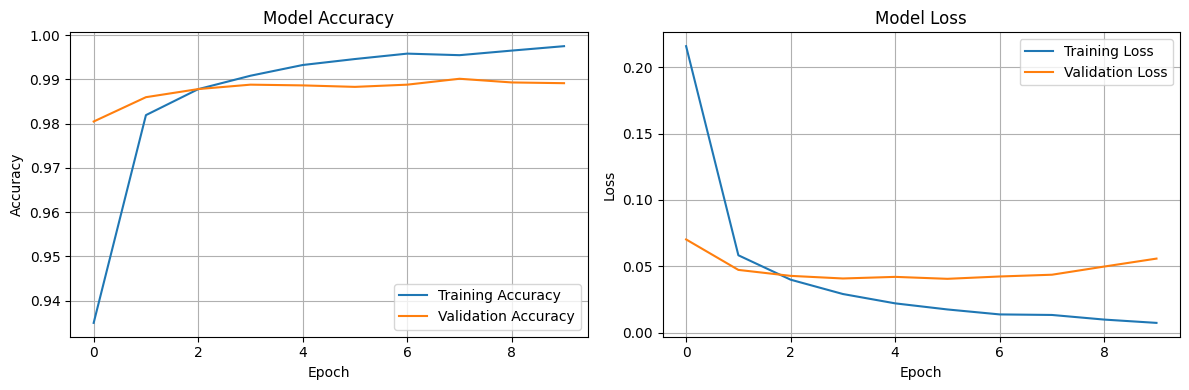


Training history saved to: lab3_images/step11_training_history.png


In [14]:
# ============================================================
# 步骤 11：训练模型
# Step 11: Fit the Model
# ============================================================
print()
print("=" * line_width)
print("Step 11: Fit the Model")
print("=" * line_width)

print(f"Training Parameters:")
print(f"  batch_size={BATCH_SIZE} - Number of samples per gradient update")
print(f"  epochs={EPOCHS} - Number of training iterations")
print(f"  validation_split={VALIDATION_SPLIT} - Fraction of data for validation")
print()

# 训练模型并记录历史
# Train the model and record history
history = model.fit(
    x_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=VALIDATION_SPLIT,
    verbose=1
)

# 绘制训练历史曲线
# Plot training history curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'step11_training_history.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTraining history saved to: {output_dir}/step11_training_history.png")

In [15]:
# ============================================================
# 步骤 12：预测测试数据
# Step 12: Predict for the Test Data
# ============================================================
print()
print("=" * line_width)
print("Step 12: Predict for the Test Data")
print("=" * line_width)

predictions = model.predict(x_test, verbose=0)

print(f"Predictions shape: {predictions.shape}")
print(f"Each prediction is a probability distribution over {NUM_CLASSES} classes")


Step 12: Predict for the Test Data
Predictions shape: (10000, 10)
Each prediction is a probability distribution over 10 classes


In [16]:
# ============================================================
# 步骤 13：打印模型准确率
# Step 13: Print the Accuracy of the Model
# ============================================================
print()
print("=" * line_width)
print("Step 13: Print the Accuracy of the Model")
print("=" * line_width)

test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")


Step 13: Print the Accuracy of the Model
Test Loss: 0.0418
Test Accuracy: 0.9890 (98.90%)


In [17]:
# ============================================================
# 步骤 14：找到每行最高概率的索引
# Step 14: Find the Index of the Highest Probability for Each Row
# ============================================================
print()
print("=" * line_width)
print("Step 14: Find the Index of the Highest Probability for Each Row")
print("=" * line_width)

# 使用 argmax 找到概率最高的类别索引
# Use argmax to find the index of highest probability class
predicted_labels = np.argmax(predictions, axis=1)
highest_probs = np.max(predictions, axis=1)

print("Method: np.argmax(predictions, axis=1)")
print(f"Predicted labels shape: {predicted_labels.shape}")
print("Example: [0.0, 0.0, 0.01, 0.0, 0.0, 0.0, 0.0, 0.99, 0.0, 0.0] -> Predicted digit: 7")


Step 14: Find the Index of the Highest Probability for Each Row
Method: np.argmax(predictions, axis=1)
Predicted labels shape: (10000,)
Example: [0.0, 0.0, 0.01, 0.0, 0.0, 0.0, 0.0, 0.99, 0.0, 0.0] -> Predicted digit: 7


In [18]:
# ============================================================
# 步骤 15：打印前 20 个预测结果
# Step 15: Print the Results for the First 20 Instances
# ============================================================
print()
print("=" * line_width)
print("Step 15: Print the Results for the First 20 Instances")
print("=" * line_width)

print()
print(f"{'Highest Probability':<22} | {'Predicted Digit':<15} | {'Actual Digit':<12}")
print("-" * line_width)

for i in range(20):
    prob = highest_probs[i]
    pred = predicted_labels[i]
    actual = y_test_original[i]
    match = "OK" if pred == actual else "X"
    print(f"[{prob:.7f}]            | {pred:<15} | {actual:<12} {match}")


Step 15: Print the Results for the First 20 Instances

Highest Probability    | Predicted Digit | Actual Digit
------------------------------------------------------------
[0.9999994]            | 7               | 7            OK
[1.0000000]            | 2               | 2            OK
[0.9999832]            | 1               | 1            OK
[1.0000000]            | 0               | 0            OK
[0.9999516]            | 4               | 4            OK
[0.9999986]            | 1               | 1            OK
[0.9999450]            | 4               | 4            OK
[0.9999852]            | 9               | 9            OK
[0.9932423]            | 5               | 5            OK
[1.0000000]            | 9               | 9            OK
[1.0000000]            | 0               | 0            OK
[0.9999982]            | 6               | 6            OK
[0.9999999]            | 9               | 9            OK
[1.0000000]            | 0               | 0            OK
[


Step 16: Print the Results for All Misclassified Instances
Total misclassified: 110 out of 10000
Misclassification rate: 1.10%

First 20 misclassified instances:

Highest Probability    | Predicted Digit | Actual Digit
------------------------------------------------------------
[0.7551149]            | 8               | 3           
[0.8483887]            | 9               | 4           
[0.8996776]            | 6               | 4           
[0.9619139]            | 0               | 6           
[0.9724038]            | 0               | 6           
[0.6954334]            | 2               | 8           
[0.6587575]            | 3               | 5           
[0.4909052]            | 2               | 7           
[0.9967830]            | 8               | 5           
[0.9856155]            | 9               | 8           
[0.9945580]            | 0               | 6           
[0.4389448]            | 8               | 6           
[0.9835567]            | 2               | 7   

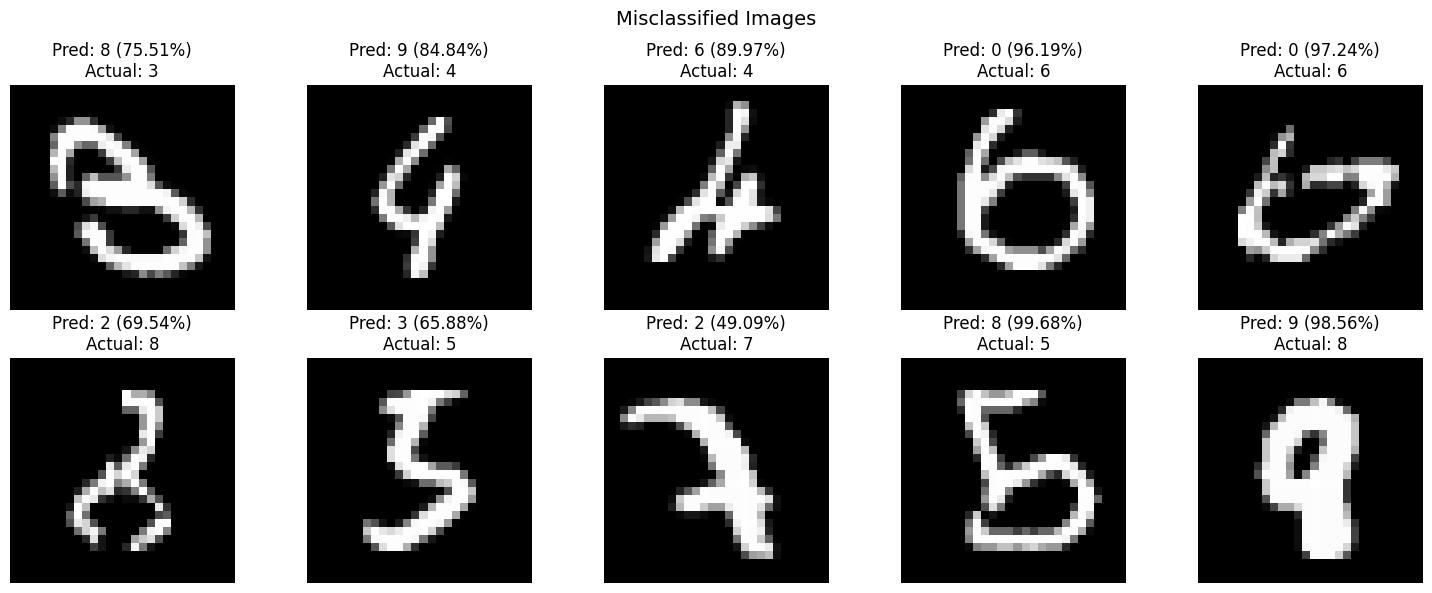


Misclassified images saved to: lab3_images/step16_misclassified_images.png


In [19]:
# ============================================================
# 步骤 16：打印所有错误分类的结果
# Step 16: Print the Results for All Misclassified Instances
# ============================================================
print()
print("=" * line_width)
print("Step 16: Print the Results for All Misclassified Instances")
print("=" * line_width)

# 找到所有预测错误的实例
# Find all incorrectly predicted instances
misclassified_indices = np.where(predicted_labels != y_test_original)[0]
num_misclassified = len(misclassified_indices)

print(f"Total misclassified: {num_misclassified} out of {len(y_test_original)}")
print(f"Misclassification rate: {num_misclassified/len(y_test_original)*100:.2f}%")
print()

display_count = min(20, num_misclassified)
print(f"First {display_count} misclassified instances:")
print()
print(f"{'Highest Probability':<22} | {'Predicted Digit':<15} | {'Actual Digit':<12}")
print("-" * line_width)

for i in range(display_count):
    idx = misclassified_indices[i]
    prob = highest_probs[idx]
    pred = predicted_labels[idx]
    actual = y_test_original[idx]
    print(f"[{prob:.7f}]            | {pred:<15} | {actual:<12}")

# 可视化部分错误分类的图像
# Visualize some misclassified images
num_to_plot = min(10, num_misclassified)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(num_to_plot):
    idx = misclassified_indices[i]
    img = x_test[idx].reshape(IMAGE_SIZE, IMAGE_SIZE)
    pred = predicted_labels[idx]
    actual = y_test_original[idx]
    prob = highest_probs[idx]

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Pred: {pred} ({prob:.2%})\nActual: {actual}")
    axes[i].axis('off')

for i in range(num_to_plot, len(axes)):
    axes[i].axis('off')

plt.suptitle("Misclassified Images", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'step16_misclassified_images.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMisclassified images saved to: {output_dir}/step16_misclassified_images.png")